# Individual homework project 1

### Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import data

In [2]:
customers = pd.read_csv("C:\\Users\\User pc\\Desktop\\MayerfeldPracticum\\data\\customers.csv")
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date
0,1,56.0,Other,Germany,referral,2019-07-21
1,2,38.0,Other,Netherlands,email,2022-03-04
2,3,28.0,Other,Australia,referral,2024-05-21
3,4,19.0,Female,Australia,paid_search,2022-06-28
4,5,38.0,Female,Australia,referral,2024-07-17


In [3]:
transactions = pd.read_csv("C:\\Users\\User pc\\Desktop\\MayerfeldPracticum\\data\\transactions.csv")
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [4]:
marketing_campaigns = pd.read_csv("C:\\Users\\User pc\\Desktop\\MayerfeldPracticum\\data\\marketing_campaigns.csv")
marketing_campaigns.head()

,campaign_id,channel,spend,impressions,clicks,conversions,date
0,1,email,32691.17,147741,11333,387,2023-10-22
1,2,display,43333.72,42596,1540,97,2024-03-09
2,3,social,47096.43,22587,1296,111,2022-03-11
3,4,email,18838.78,145817,4609,307,2019-11-04
4,5,paid_search,36828.43,92450,4842,514,2022-03-30


In [5]:
web_sessions = pd.read_csv("C:\\Users\\User pc\\Desktop\\MayerfeldPracticum\\data\\web_sessions.csv")
web_sessions.head()

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0
1,2,4617,5,257.386842,mobile,social,2020-07-03,0
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0
4,5,6245,3,339.228209,mobile,email,2019-04-02,0


### Specific questions

### Q1. What is the average purchase value for customers from Spain?

In [6]:
customers_transactions = transactions.merge(customers, on='customer_id')
customers_transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date,age,gender,country,acquisition_channel,signup_date
0,1,8141,home,74.32,0,2023-09-05,39.0,Male,UK,social,2021-04-13
1,2,1297,fashion,17.51,0,2019-08-07,43.0,Female,Spain,email,2024-03-10
2,3,7930,toys,39.96,1,2020-02-07,19.0,Male,Netherlands,referral,2022-11-28
3,4,2426,electronics,43.79,0,2020-10-02,67.0,Female,Australia,referral,2023-09-14
4,5,6614,fashion,187.01,0,2023-09-15,50.0,Other,Germany,paid_search,2021-10-20


In [7]:
customers_transactions.groupby(by='country')['purchase_value'].mean()['Spain']

75.63200247875353

### Q2. What is the minimum purchase value for customers from Germany?

In [8]:
customers_transactions.groupby(by='country')['purchase_value'].min()['Germany']

0.39

### Q3. How much did males spend on buying products in the Sports category?

In [9]:
customers_transactions.groupby(['gender','product_category'])['purchase_value'].sum()
# Answer is 191184.72

gender  product_category
Female  beauty              198989.59
        electronics         185349.54
        fashion             195770.37
        home                187358.38
        sports              189450.56
        toys                190212.35
Male    beauty              193193.53
        electronics         190557.06
        fashion             194914.78
        home                196015.07
        sports              191184.72
        toys                185276.83
Other   beauty              189678.19
        electronics         177453.84
        fashion             188949.37
        home                191263.69
        sports              187025.43
        toys                180278.38
Name: purchase_value, dtype: float64

### Q4. What is the average age of female customers from Canada?

In [10]:
customers_transactions.groupby(['gender','country'])['age'].mean()
# Answer is 43.065352

gender  country    
Female  Australia      43.916448
        Canada         43.065352
        France         42.854217
        Germany        44.577966
        Netherlands    44.993594
        Spain          43.267156
        UK             41.795679
        US             43.627907
Male    Australia      44.274164
        Canada         42.962117
        France         42.512882
        Germany        43.781871
        Netherlands    43.081531
        Spain          43.314573
        UK             43.792193
        US             43.131680
Other   Australia      45.708082
        Canada         43.565318
        France         44.552960
        Germany        42.446078
        Netherlands    42.978335
        Spain          43.436433
        UK             43.626021
        US             43.793358
Name: age, dtype: float64

### Q5. How much does an average male customer from the UK spend?

In [11]:
customers_transactions.groupby(['gender','country'])['purchase_value'].mean()
# Answer is 76.625302

gender  country    
Female  Australia      74.411914
        Canada         75.286563
        France         75.970338
        Germany        76.043552
        Netherlands    74.585009
        Spain          75.617409
        UK             73.863761
        US             76.498024
Male    Australia      76.257592
        Canada         75.295666
        France         76.747687
        Germany        75.325501
        Netherlands    76.435079
        Spain          74.826133
        UK             76.625302
        US             76.837436
Other   Australia      76.125811
        Canada         79.752147
        France         74.633268
        Germany        75.919363
        Netherlands    75.367360
        Spain          76.536523
        UK             76.212423
        US             75.150356
Name: purchase_value, dtype: float64

### Q6. What is the maximum purchase value for females in the Toys category?

In [12]:
customers_transactions.groupby(['gender','product_category'])['purchase_value'].max()
# Answer is 423.84

gender  product_category
Female  beauty               949.52
        electronics          424.12
        fashion             1269.68
        home                 362.28
        sports              1275.28
        toys                 423.84
Male    beauty               691.52
        electronics         1000.64
        fashion             1177.92
        home                1995.28
        sports               860.00
        toys                1253.68
Other   beauty               976.96
        electronics          513.76
        fashion              569.28
        home                1294.00
        sports               536.08
        toys                1201.12
Name: purchase_value, dtype: float64

### Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [13]:
web_sessions.groupby(['converted'])['pages_viewed'].mean()

# Assuming that those who made purchase(convert) are assigned categorical value of 1. The average value is 5.728620
# Answer is 5.728620

converted
0    4.885475
1    5.728620
Name: pages_viewed, dtype: float64

### Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [14]:
web_sessions.groupby(['converted'])['time_on_site'].mean()

# Non-purchasing customers is 299.238547 while purchasing customers is 311.194837


converted
0    299.238547
1    311.194837
Name: time_on_site, dtype: float64

### Visualisation tasks

### Q9. Plot purchasing value across years.

In [15]:
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date']) #converting puchase_date to datetime
yearly_summary = transactions.groupby(transactions['purchase_date'].dt.year)['purchase_value'].sum()
yearly_summary = pd.DataFrame(yearly_summary) #converting from series to DataFrame
yearly_summary

,purchase_value
purchase_date,
2019,569762.92
2020,573614.84
2021,564950.10
2022,575119.69
2023,567331.56
2024,562142.57


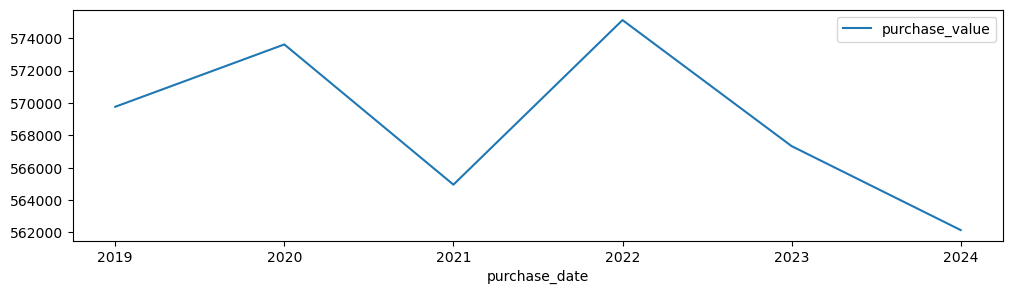

In [16]:
yearly_summary.plot(figsize=(12,3));   # line plot of purchase_value by yearly purchase_date

### Q10. Plot purchasing value across product categories.

In [17]:
product_category_by_purchase_value = transactions.groupby(transactions['product_category'])['purchase_value'].sum()
product_category_by_purchase_value = pd.DataFrame(product_category_by_purchase_value)
product_category_by_purchase_value

,purchase_value
product_category,
beauty,581861.31
electronics,553360.44
fashion,579634.52
home,574637.14
sports,567660.71
toys,555767.56


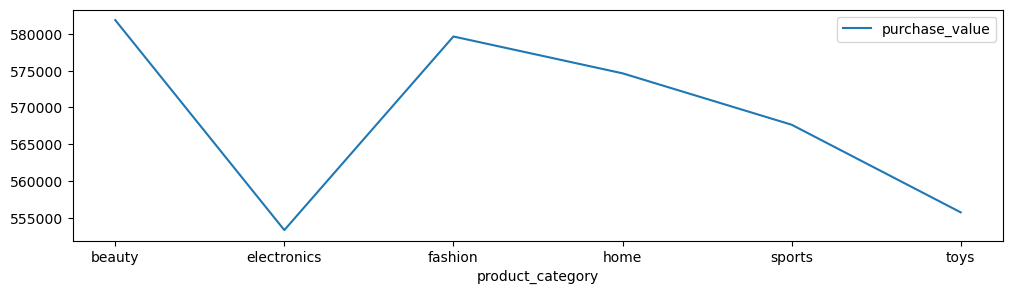

In [18]:
product_category_by_purchase_value.plot(figsize=(12,3));

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

In [19]:
customers_sessions = web_sessions.merge(customers, on='customer_id')
customers_sessions.head()

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted,age,gender,country,acquisition_channel,signup_date
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0,57.0,Other,Canada,organic,2020-11-04
1,2,4617,5,257.386842,mobile,social,2020-07-03,0,27.0,Female,Australia,social,2023-07-02
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0,24.0,Female,Germany,organic,2019-10-11
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0,69.0,Female,Germany,Email,2021-12-19
4,5,6245,3,339.228209,mobile,email,2019-04-02,0,NaN,Other,Canada,paid_search,2019-05-20


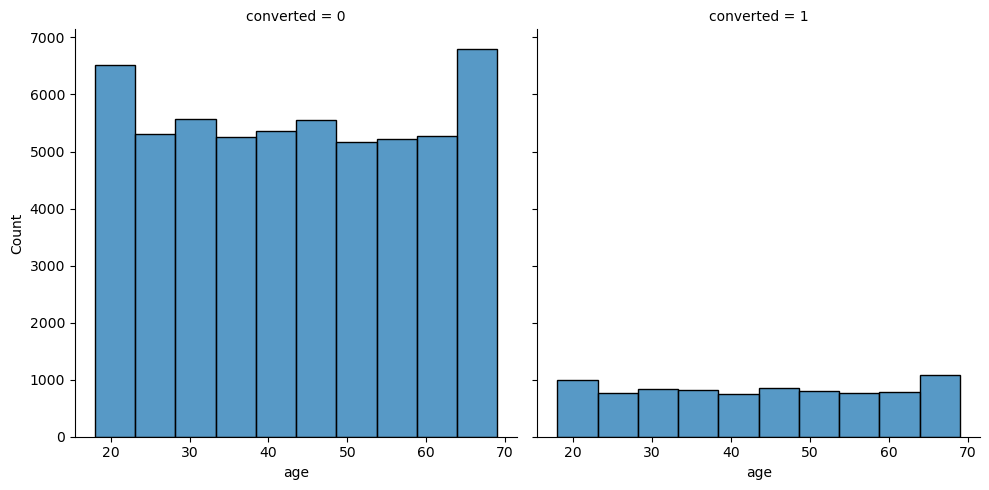

In [20]:
sns.displot(data=customers_sessions, x='age', bins=10, col='converted', kind = 'hist'); 

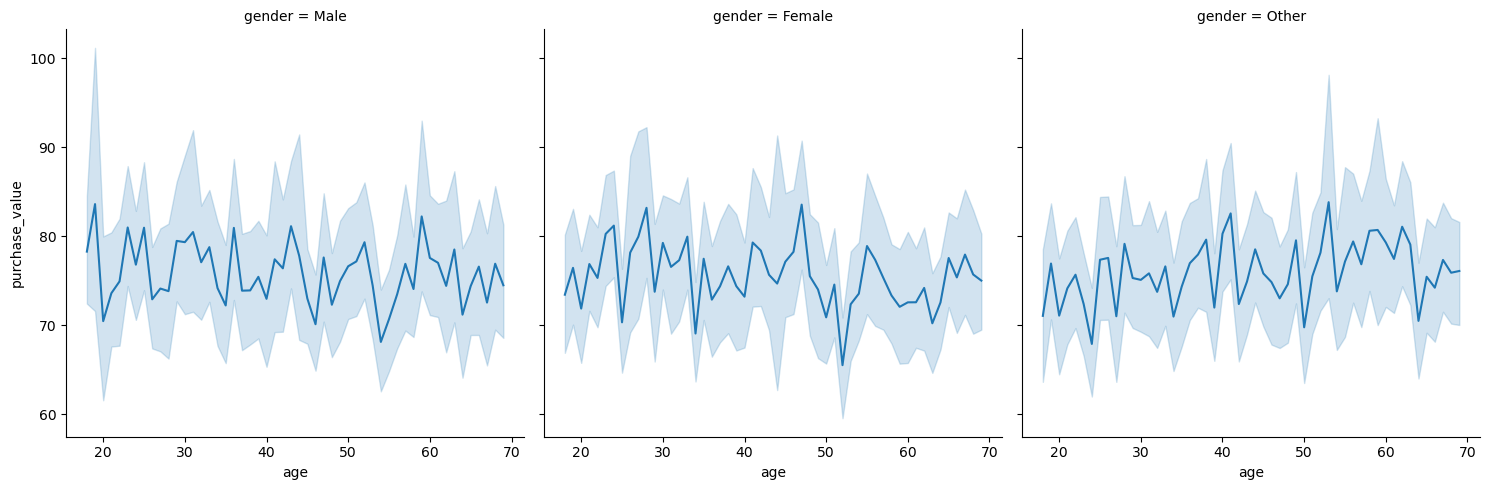

In [21]:
sns.relplot(data=customers_transactions, x='age', y='purchase_value', kind = 'line', col='gender');

 ### Identify three patterns in the data

    1. As purchase date increases yearly, purchase value does not increase or decrease in line with it.No relationsip beween the two
    
    2. Increase in age does not lead to increase or decrease in purchase value of the products. No relationship between age of customers and purchase value of the products

    3. With expectation of 5% convertion rate for a fruitfull marketing campaign. We can see from the bar chart that those who converted are greater than or equal to 5% across each age category . Thus, we conclude that the marketing campaign was succefull and fruitfull
    

 ### Write five insights in plain English explaining what the data tells us
    
    1. Product category with highest purchase value is Beauty and lowest purchase value goes to electronics. While year 2022 has highest purchase value and year 2024 has lowest purchase value
    
    2. The male gender has their highest purchase value at age 0-20 while lowest purchase value comes from the  mid 50's years.
    
    3. The female gender has their highest purchase value from the late 20's years and late 40's years while lowest purchase value is  from the early 50's years 
    
    4. Across all gender, the highest purchase value of the products came from those between age 0-20 years of age
    
    5. Highest percentage of those who did not convert are within age 10-25years and 65-70years